[[0.70175603]
 [1.31428697]
 [1.41994619]
 [0.57083276]
 [1.48244227]]
[[5.88694252]
 [7.43016733]
 [7.74764902]
 [5.3412848 ]
 [8.35508716]]


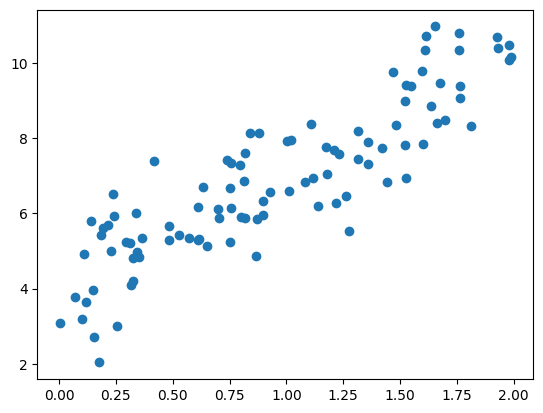

In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = 2 * np.random.rand(100,1) # 100 rows × 1 column
print(X[:5])
Y =  4 + 3 * X + np.random.randn(100, 1) # Normal (Gaussian)
print(Y[:5])
plt.scatter(X,Y)
plt.show()

In [2]:
# let’s compute θˆ using the Normal Equation
X_b = np.c_[np.ones((100, 1)), X] # SHOUT BIAS
''' IMPORTANT '''
'''We will use the inv()
function from NumPy’s linear algebra module (np.linalg) to compute the
inverse of a matrix, and the dot() method for matrix multiplication:'''
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)
'''y = 4 + 3x1 + Gaussian noise'''

'y = 4 + 3x1 + Gaussian noise'

In [3]:
theta_best

array([[3.89702014],
       [3.13106555]])

In [4]:
''' θ1 = 3.4 and θ2 = 0.75'''
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)), X_new] # add Bias
y_predict = X_new_b.dot(theta_best)
y_predict

array([[ 3.89702014],
       [10.15915123]])

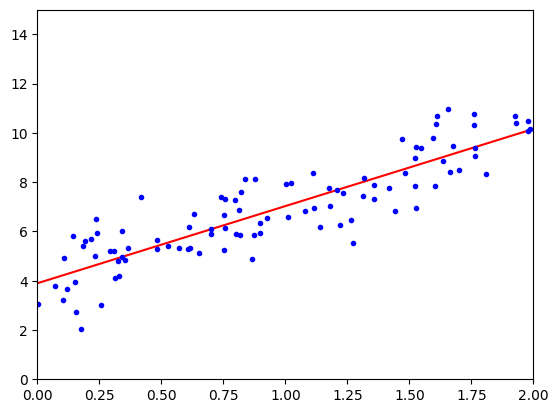

In [5]:
plt.plot(X_new, y_predict, "r-")
plt.plot(X, Y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [6]:
''' Moore-Penrose inverse '''
np.linalg.pinv(X_b).dot(Y)  # PROOF PENDING

array([[3.89702014],
       [3.13106555]])

In [7]:
''' Standardize features (mean 0, variance 1), or Normalize to a similar range '''

' Standardize features (mean 0, variance 1), or Normalize to a similar range '

## Gradient Descent

In [8]:
eta = 0.1
n_iterations = 1000
m = 100

theta = np.random.randn(2, 1)
for iteration in range(n_iterations):
    grad = 2 / m * X_b.T.dot(X_b.dot(theta) - Y)
    theta = theta - eta * grad

theta    

array([[3.89702014],
       [3.13106555]])

## SGD

In [9]:
n_epochs = 50
t0, t1 = 5, 50   # Learning Schedule PARAMS
def learning(t):
    return t0 / (t + t1)
theta = np.random.randn(2,1)
for epoch in range(n_epochs):
    for i in range(m):
        index = np.random.randint(m)
        xi =  X_b[index:index+1]
        yi = Y[index:index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta)-yi)
        eta = learning(epoch * m + i)
        theta = theta - eta * gradients
''' Batch Gradient Descent code iterated 1,000 times through the whole training set, this code goes through the training set only 50 times and reaches a pretty good solution '''

' Batch Gradient Descent code iterated 1,000 times through the whole training set, this code goes through the training set only 50 times and reaches a pretty good solution '

In [10]:
theta

array([[3.9531754 ],
       [3.12748812]])

## Polynomial Regression

[[ 1.48816765]
 [-2.48503699]
 [ 0.41323353]
 [-0.55875316]
 [ 1.11157817]]
[[5.39283785]
 [3.87325087]
 [3.88648766]
 [1.1304101 ]
 [4.51178916]]


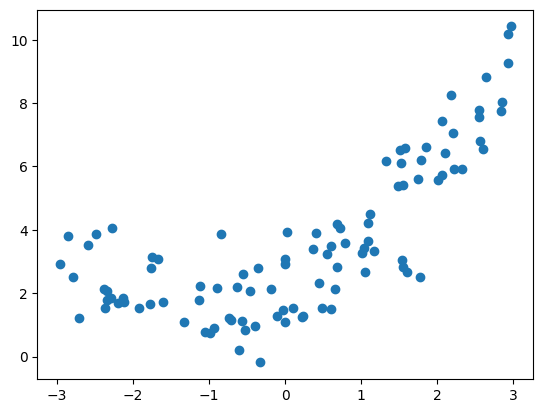

In [11]:
import numpy as np
import matplotlib.pyplot as plt
m = 100
X = 6 * np.random.rand(m,1) - 3
Y = 0.45 * X ** 2 + X + 2 + np.random.randn(m, 1) 
print(X[:5])
print(Y[:5])
plt.scatter(X, Y)
plt.show()


In [12]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print(X[0])
print(X_poly[0]) # Extra coloumns for sq of each feature

[1.48816765]
[1.48816765 2.21464295]


In [13]:
from sklearn.linear_model import LinearRegression
a = LinearRegression()
a.fit(X_poly, Y)
a.intercept_, a.coef_

(array([2.0993436]), array([[1.00146616, 0.4734964 ]]))

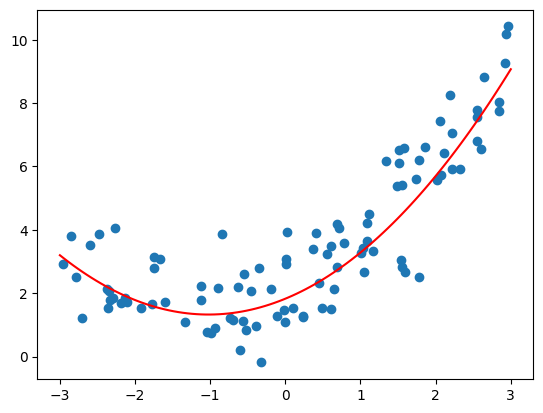

In [14]:
x = np.linspace(-3,3,100)
y = 0.4785362*x**2 + 0.97837064*x + 1.82805253
plt.plot(x, y, "r")
plt.scatter(X, Y)
plt.show()

## FUCCK AROUND AND FIND OUT

## Learning Curve

In [15]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
def plot_lc(model, X, Y):
    X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2)
    t_e, v_e = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], Y_train[:m])
        Y_train_p = model.predict(X_train[:m])
        Y_val_p = model.predict(X_val) # SIZE REMIAIN FIXED AT EACH ITERATION
        t_e.append(mean_squared_error(Y_train[:m], Y_train_p))
        v_e.append(mean_squared_error(Y_val, Y_val_p))
    plt.ylim(0, 5)  
    plt.plot(np.sqrt(t_e), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(v_e), "b--", linewidth=2, label="test")      
    

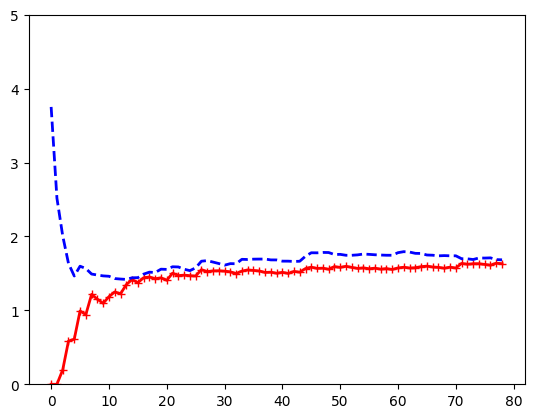

In [16]:
plot_lc(a, X, Y) # UNDERFIT

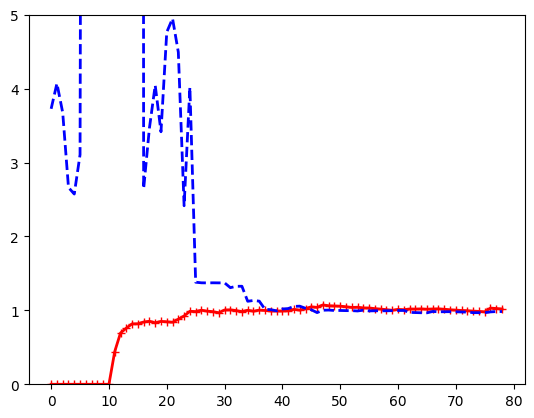

In [17]:
## LETS USE A CURVE OF deg = 10
from sklearn.pipeline import Pipeline
polynomial_regression = Pipeline([
("poly_features", PolynomialFeatures(degree=10,
include_bias=False)),
("a", LinearRegression()),
])
plot_lc(polynomial_regression, X, Y) # OVERFIT

## REGULARIZED REGRESSION

## Ridge Regression

In [18]:
# θ = ((X .T * X + αA) ^ -1 ) * (X.T * Y)

In [19]:
## IN GD
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky")  # Cholesky solver computes this using Cholesky decomposition
ridge_reg.fit(X, Y)
ridge_reg.predict([[1.5]])

array([4.98871508])

In [20]:
## IN SGD
from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(penalty="l2") # Penalty here is 
sgd_reg.fit(X, Y.ravel()) # SGDRegressor expects a 1D target vector
sgd_reg.predict([[1.5]])


array([4.95423513])

In [21]:
'''Specifying "l2" indicates that you want SGD to add a regularization term to the cost function equal to half the square of the ℓ2 norm of the weight vector: this is simply Ridge Regression.'''

'Specifying "l2" indicates that you want SGD to add a regularization term to the cost function equal to half the square of the ℓ2 norm of the weight vector: this is simply Ridge Regression.'

## Lasso Regression

In [22]:
from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, Y)
lasso_reg.predict([[1.5]])

array([4.94629798])

## Elastic Net

In [23]:
from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, Y)
elastic_net.predict([[1.5]])

array([4.94595182])

 (run at your own risk)

## WITH THIS TREASURE, I SUMMON LINEAR REGRESSION

In [24]:
# IRIS DATASET

In [25]:
from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [26]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [27]:
X = iris["data"][:, 3:] # petal width
Y = (iris["target"] == 2).astype(int) # 1 if Iris virginica, else 0

from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X, Y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


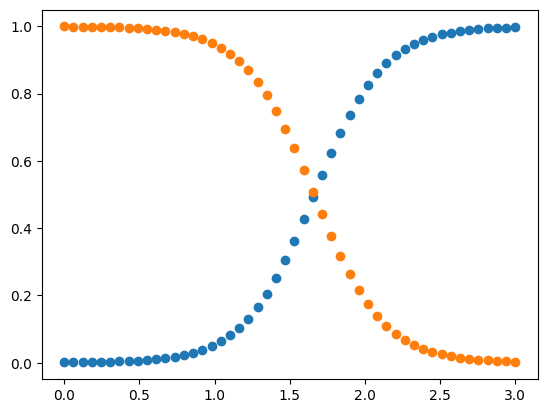

In [28]:
X_new = np.linspace(0, 3, 50).reshape(50, 1)
y_proba = log_reg.predict_proba(X_new)
plt.scatter(X_new, y_proba[:, 1],  label="Iris virginica")
plt.scatter(X_new, y_proba[:, 0],  label="Not Iris virginica")
plt.show()

In [29]:
log_reg.predict([[1.7], [1.5]])

array([1, 0])

In [30]:
## Soft-Max regression

In [31]:
X = iris["data"][:, (2, 3)] # petal length, petal width
y = iris["target"]

In [32]:
softmax_reg = LogisticRegression(multi_class="multinomial",solver="lbfgs",C=10)
#It also applies ℓ2 regularization by default, which you can control using the hyperparameter C

In [33]:
softmax_reg.fit(X, y)

/home/sarvadubey/Desktop/ML/Linear_REG/venv/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,10
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [34]:
softmax_reg.predict([[5, 2]])

array([2])

In [35]:
softmax_reg.predict_proba([[5, 2]])

array([[6.21626374e-07, 5.73689802e-02, 9.42630398e-01]])